In [2]:
import random
import time
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt
from cs231n.classifiers import KNearestNeighbor
from cs231n.classifiers import Softmax
from cs231n.classifiers import LinearSVM
from cs231n.classifiers.fc_net import *
from cs231n.solver import Solver
from cs231n.data_utils import get_CIFAR10_data

In [3]:

cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)


X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))


data = get_CIFAR10_data()

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 3072)
Training labels shape:  (50000,)
Test data shape:  (10000, 3072)
Test labels shape:  (10000,)


In [4]:
knn = KNearestNeighbor()
svm = LinearSVM()
softmax = Softmax()

input_size = 32 * 32 * 3
hidden_size = 100
num_classes = 10
hidden_dims = [300]
model = FullyConnectedNet(hidden_dims, input_size, num_classes,weight_scale=1e-3,reg=0.5,dropout_keep_ratio=0.5)

solver = Solver(model, data,
                    update_rule='sgd',
                    optim_config={
                      'learning_rate': 5e-4,
                    },
                    lr_decay=0.9,
                    num_epochs=5, batch_size=200,
                    print_every=1000,)



loss1 = knn.train(X_train[:8000,:],y_train[:8000])
loss2 = svm.train(X_train,y_train,learning_rate=8e-9, reg=1e5,num_iters=2500,verbose=True,verbose_num=1250)
loss3 = softmax.train(X_train,y_train,learning_rate=1e-7, reg=1e4,num_iters=2500,verbose=True,verbose_num=1250)
solver.train()

iteration 1250 / 2500: loss 61.659851
iteration 2500 / 2500: loss 7.644926
iteration 1250 / 2500: loss 3.992893
iteration 2500 / 2500: loss 1.980799
(Iteration 1 / 1225) loss: 2.534388
(Epoch 0 / 5) train acc: 0.133000; val_acc: 0.147000
(Epoch 1 / 5) train acc: 0.400000; val_acc: 0.397000
(Epoch 2 / 5) train acc: 0.439000; val_acc: 0.448000
(Epoch 3 / 5) train acc: 0.472000; val_acc: 0.470000
(Epoch 4 / 5) train acc: 0.502000; val_acc: 0.475000
(Iteration 1001 / 1225) loss: 1.725861
(Epoch 5 / 5) train acc: 0.493000; val_acc: 0.475000


In [5]:

y_train_pred2 = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred2), ))
y_train_pred3 = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred3), ))

training accuracy: 0.342680
training accuracy: 0.343960


In [6]:

start_time = time.time()

y_test_pred1 = knn.predict(X_test, k=8)
knn_time = time.time() - start_time
print('knn accuracy: %f' % (np.mean(y_test_pred1 == y_test),))


start_time = time.time()
y_test_pred2 = svm.predict(X_test)
svm_time = time.time() - start_time
print('Linear SVM accuracy: %f' % (np.mean(y_test_pred2 == y_test),))


start_time = time.time()
y_test_pred3 = softmax.predict(X_test)
softmax_time = time.time() - start_time
print('softmax accuracy: %f' % (np.mean(y_test_pred3 == y_test),))


start_time = time.time()
y_test_pred4 = np.argmax(model.loss(data['X_test']), axis=1)
fc_net_time = time.time() - start_time
print('fc-net accuracy: %f' % (np.mean(y_test_pred4 == data['y_test']),))


end_time = time.time()
print('\nTotal execution time: %.2f seconds' % (end_time - start_time + knn_time + svm_time + softmax_time,))
print(f'\n=== Prediction Time Summary ===')
print(f'KNN: {knn_time:.2f} seconds')
print(f'SVM: {svm_time:.2f} seconds')
print(f'Softmax: {softmax_time:.2f} seconds')
print(f'FC-net: {fc_net_time:.2f} seconds')


knn accuracy: 0.285200
Linear SVM accuracy: 0.340400
softmax accuracy: 0.341900
fc-net accuracy: 0.483000

Total execution time: 5.72 seconds

=== Prediction Time Summary ===
KNN: 5.69 seconds
SVM: 0.01 seconds
Softmax: 0.01 seconds
FC-net: 0.01 seconds


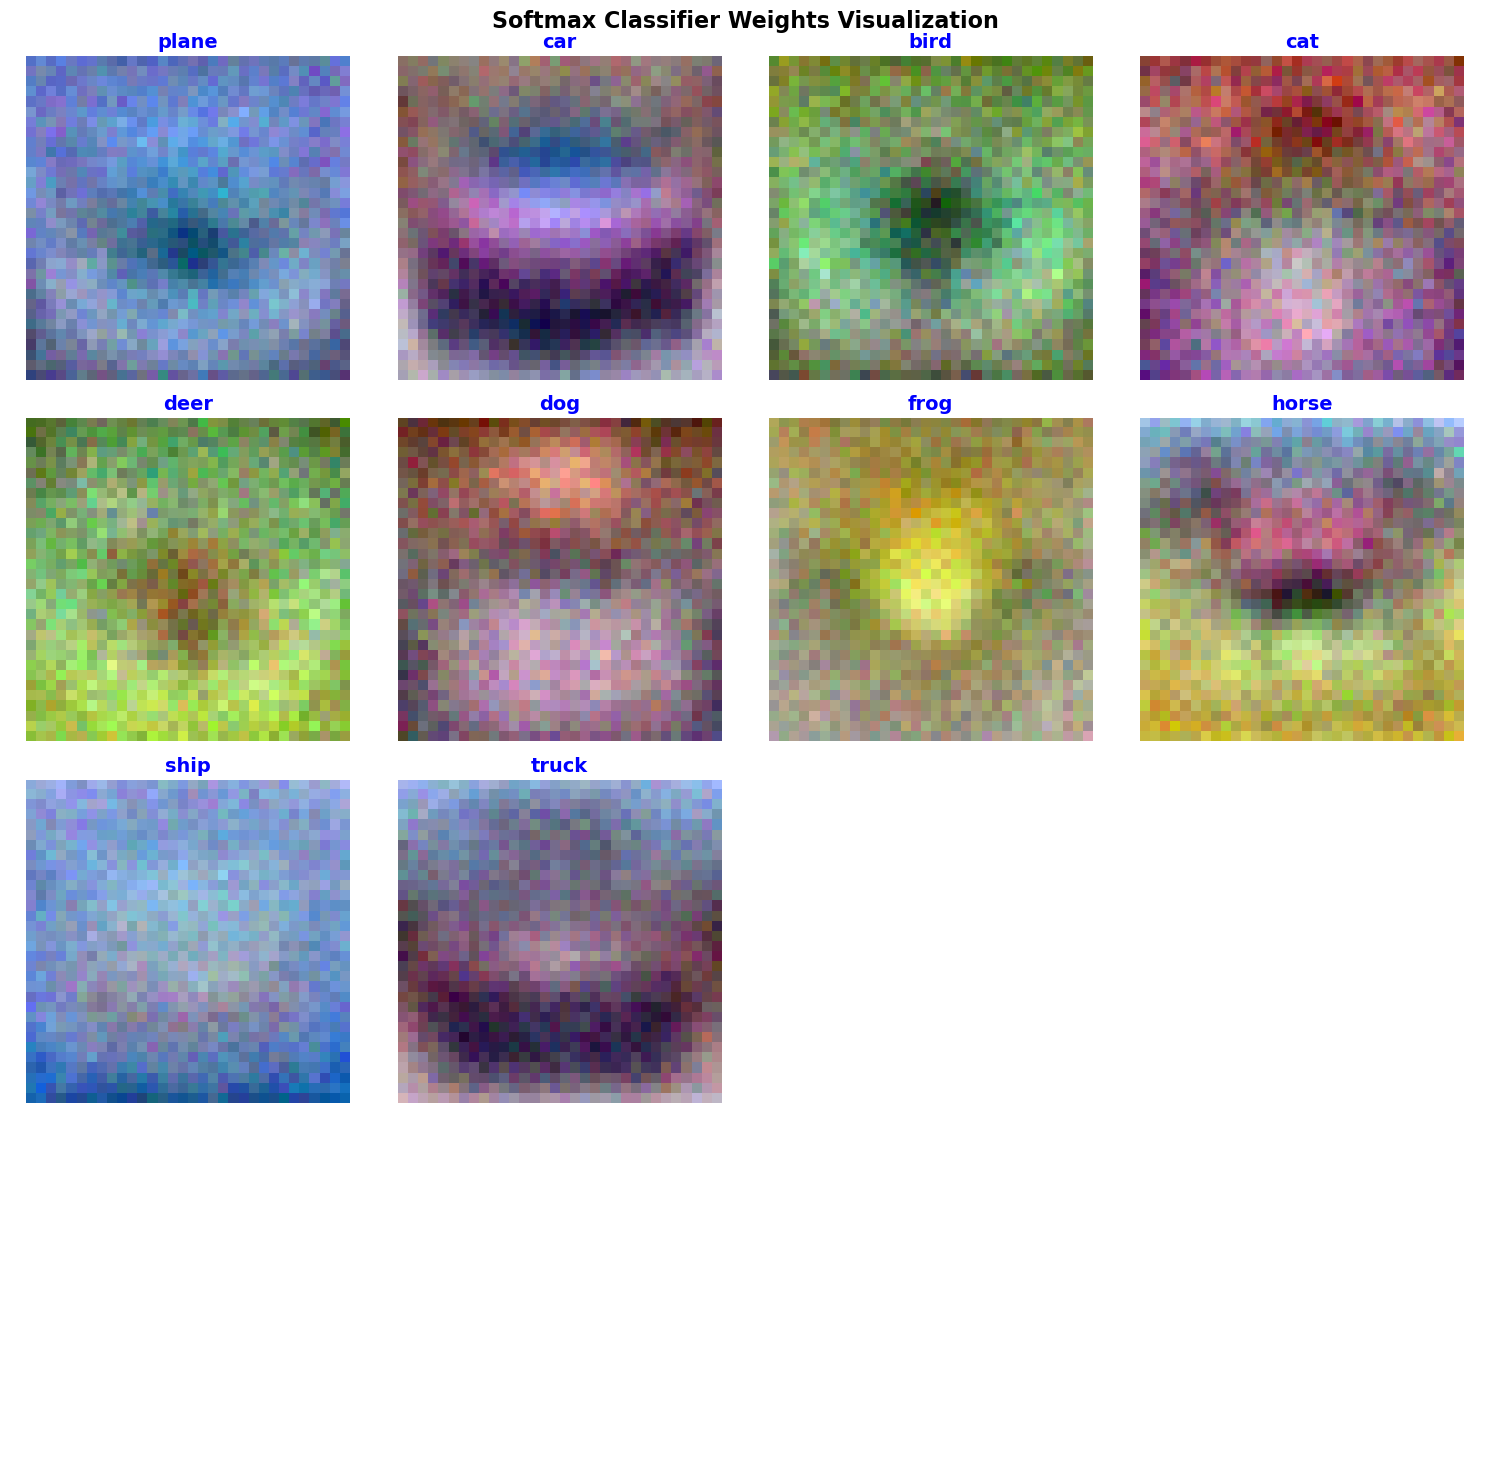

In [16]:
from math import ceil, sqrt

def visualize_weights_with_labels(W, classes, input_shape=(32, 32, 3), ubound=255.0, padding=1):

    """
    可视化 Softmax 分类器的权重矩阵 W，并为每个图像添加类别标签
    
    Inputs:
    - W: 权重矩阵，形状为 (D, C)，其中 D 是输入维度，C 是类别数
    - classes: 类别名称列表
    - input_shape: 输入数据的原始形状，默认为 CIFAR-10 的 (32, 32, 3)
    - ubound: 输出网格的值范围上限，默认为 255.0
    - padding: 网格元素之间的空白像素数，默认为 1
    
    Returns:
    - grid: 可视化网格图像数组
    """
    D, C = W.shape
    H, W_ch, C_channels = input_shape
    
    assert len(classes) == C, "类别数量必须与权重矩阵的列数一致"
    
    # 将每个类别的权重重塑为图像形状 (H, W, C)
    weight_images = np.zeros((C, H, W_ch, C_channels))
    for i in range(C):
        weight_images[i] = W[:, i].reshape(H, W_ch, C_channels)
    
    # 计算网格大小
    grid_size = int(ceil(sqrt(C)))
    
    # 创建图形和子图
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    if grid_size == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # 绘制每个类别的权重图像
    for i in range(C):
        img = weight_images[i]
        low, high = np.min(img), np.max(img)
        
        # 归一化到 [0, 1]
        if high > low:
            norm_img = (img - low) / (high - low)
        else:
            norm_img = img * 0
        
        axes[i].imshow(norm_img)
        axes[i].set_title(f'{classes[i]}', fontsize=14, fontweight='bold', color='blue')
        axes[i].axis('off')
    
    # 隐藏多余的子图
    for i in range(C, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Softmax Classifier Weights Visualization', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 同时返回网格数组（可选）
    grid_height = H * grid_size + padding * (grid_size - 1)
    grid_width = W_ch * grid_size + padding * (grid_size - 1)
    grid = np.zeros((grid_height, grid_width, C_channels))
    
    next_idx = 0
    y0, y1 = 0, H
    for y in range(grid_size):
        x0, x1 = 0, W_ch
        for x in range(grid_size):
            if next_idx < C:
                img = weight_images[next_idx]
                if high > low:
                    grid[y0:y1, x0:x1] = ubound * (img - low) / (high - low)
                else:
                    grid[y0:y1, x0:x1] = ubound / 2
                next_idx += 1
            x0 += W_ch + padding
            x1 += W_ch + padding
        y0 += H + padding
        y1 += H + padding
    
    return grid
#ai生成
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
g = visualize_weights_with_labels(softmax.W, classes)

# 模型比较
knn的核心是比较test图像和train图像中每个像素的距离差值，然后求和，求和越小，则越相似。但这样有些问题，若两者只是背景颜色相似，但主体完全不同。这样的图片差值同样很小，却完全不是正确分类。在我的理解中knn主要依靠图像的色块特征来分类，而难以注意到线条形状特征。同时knn的模型不需要训练，但其运行成本极高，要将test集与train集全体进行对比。花费时间极长。  

而svm和softmax则很好解决了运行成本大的问题。通过训练模型得到训练好的参数w和b。将类别图像的关键特征保存到训练好的参数中(可以看出各个类别对应的w参数其实和其类别图像有相似之处)。这样在运行时只要进行矩阵运算，大大节省了运行时间。  

而svm和softmax的区别在于不同分类方式和loss函数。svm要找到一个超平面使得各个类别的score差值尽可能大，而softmax则将score转化为概率，并希望这个概率尽可能大。  
两者最终效果是差不多的，但svm并非处处可导，softmax则处处可导。我认为这应该算是在后续更复杂模型中更倾向使用softmax的原因之一。  

而多层神经网络则引入relu激活函数，以此模拟人脑神经网络需要一个激活阈值的过程（若没有激活阈值，由于矩阵乘法的结合性，网络应该会退化为一层模型——个人猜测）。这使得模型能提取更加抽象复杂的特征，也使得模型判断更准确。


# 数学准备

最麻烦的步骤是在反向传播时，计算矩阵乘法的导  
``` 
# forward pass
W = np.random.randn(5, 10)
X = np.random.randn(10, 3)
D = W.dot(X)

# now suppose we had the gradient on D from above in the circuit
dD = np.random.randn(*D.shape) # same shape as D
dW = dD.dot(X.T) #.T gives the transpose of the matrix
dX = W.T.dot(dD)
```
以上是矩阵乘法求导的公式（我认为只是最不好理解的部分，dD/dW恰好是X.T,然后恰好与dL/dD进行矩阵运算）。然后我们还需要其他各部分的求导公式（像relu，softmax，svm之类的）。最后基于链式法则，上一步的dX恰好就是下一步的dD，最后可以求出各个部分关于loss的导。